In [13]:
# Importar librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [4]:
pbp = pd.read_excel("C:/Users/jorge/OneDrive/Escritorio/Portafolio/financial_loan.xlsx")

In [5]:
# --- Valores únicos por columna ---
valores_unicos = []
for col in pbp.columns:
    unicos = pbp[col].dropna().unique()
    valores_unicos.append({
        "Columna": col,
        "Cantidad de valores únicos": len(unicos),
        "Valores únicos": list(unicos)
    })
df_unicos = pd.DataFrame(valores_unicos)

# --- Resumen de nulos ---
df_nulos = pbp.isna().sum().reset_index()
df_nulos.columns = ["Columna", "Cantidad de nulos"]

# --- Resumen de atípicos ---
resumen_outliers = []
for col in pbp.select_dtypes(include='number').columns:
    pbp_mean = pbp[col].mean(skipna=True)
    pbp_desv = pbp[col].std(skipna=True)

    if pbp[col].notna().sum() > 1 and pbp_desv != 0:
        z_score = (pbp[col] - pbp_mean) / pbp_desv
        max_abs = z_score.abs().max(skipna=True)

        if pd.notna(max_abs):
            max_abs_int = int(max_abs)
            valores_unicos = pbp.loc[z_score.abs() >= max_abs_int, col].unique()
            resumen_outliers.append({
                "Columna": col,
                "Max Zscore (abs, entero)": max_abs_int,
                "Cantidad de valores únicos": len(valores_unicos),
                "Valores únicos": list(valores_unicos)
            })
df_outliers = pd.DataFrame(resumen_outliers)

# --- Exportar todo a un mismo Excel ---
with pd.ExcelWriter("C:/Users/jorge/OneDrive/Escritorio/Portafolio/resumen_limpieza.xlsx") as writer:
    df_unicos.to_excel(writer, sheet_name="Valores Únicos", index=False)
    df_nulos.to_excel(writer, sheet_name="Resumen Nulos", index=False)
    df_outliers.to_excel(writer, sheet_name="Resumen Atípicos", index=False)

In [34]:
#Columnas que no sirven para el analisis
pbp_simplificado = pbp.drop(["id", "application_type", "emp_title", "member_id",
                            "issue_date", "last_credit_pull_date", "last_payment_date", 
                             "next_payment_date"], axis=1)

In [35]:
#Esto se hace para intentar calcular esta variable
baremo_status = {
    "Fully Paid": 0,
    "Current": 0,
    "Charged Off": 1
}

pbp_simplificado["loan_status"] = pbp_simplificado["loan_status"].map(baremo_status)

pbp_simplificado.head()

,address_state,emp_length,grade,home_ownership,loan_status,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,GA,< 1 year,C,RENT,1,car,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,CA,9 years,E,RENT,0,car,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,CA,4 years,C,RENT,1,car,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,TX,< 1 year,B,MORTGAGE,0,car,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,IL,10+ years,A,MORTGAGE,0,car,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [36]:
pbp_encoded = pd.get_dummies(pbp_simplificado, columns=["address_state", "emp_length", "grade", "term",
                                        "home_ownership", "purpose", "sub_grade",
                                          "verification_status"])
pbp_encoded.head()

,loan_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment,address_state_AK,address_state_AL,address_state_AR,address_state_AZ,address_state_CA,address_state_CO,address_state_CT,address_state_DC,address_state_DE,address_state_FL,address_state_GA,address_state_HI,address_state_IA,address_state_ID,address_state_IL,address_state_IN,address_state_KS,address_state_KY,address_state_LA,address_state_MA,address_state_MD,address_state_ME,address_state_MI,address_state_MN,address_state_MO,address_state_MS,address_state_MT,address_state_NC,address_state_NE,address_state_NH,address_state_NJ,address_state_NM,address_state_NV,address_state_NY,address_state_OH,address_state_OK,address_state_OR,address_state_PA,address_state_RI,address_state_SC,address_state_SD,address_state_TN,address_state_TX,address_state_UT,address_state_VA,address_state_VT,address_state_WA,address_state_WI,address_state_WV,address_state_WY,emp_length_1 year,emp_length_10+ years,emp_length_2 years,emp_length_3 years,emp_length_4 years,emp_length_5 years,emp_length_6 years,emp_length_7 years,emp_length_8 years,emp_length_9 years,emp_length_< 1 year,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,term_ 36 months,term_ 60 months,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_Debt consolidation,purpose_car,purpose_credit card,purpose_educational,purpose_home improvement,purpose_house,purpose_major purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small business,purpose_vacation,purpose_wedding,sub_grade_A1,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified
0,1,30000.0,0.0100,59.83,0.1527,2500,4,1009,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,48000.0,0.0535,109.43,0.1864,3000,4,3939,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,50000.0,0.2088,421.65,0.1596,12000,11,3522,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

In [37]:
#Es para ver la cantidad de columnas 
pbp_encoded.info()

#Es para imprimir las columnas 
print(list(pbp_encoded.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Columns: 135 entries, loan_status to verification_status_Verified
dtypes: bool(127), float64(4), int64(4)
memory usage: 7.0 MB
['loan_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment', 'address_state_AK', 'address_state_AL', 'address_state_AR', 'address_state_AZ', 'address_state_CA', 'address_state_CO', 'address_state_CT', 'address_state_DC', 'address_state_DE', 'address_state_FL', 'address_state_GA', 'address_state_HI', 'address_state_IA', 'address_state_ID', 'address_state_IL', 'address_state_IN', 'address_state_KS', 'address_state_KY', 'address_state_LA', 'address_state_MA', 'address_state_MD', 'address_state_ME', 'address_state_MI', 'address_state_MN', 'address_state_MO', 'address_state_MS', 'address_state_MT', 'address_state_NC', 'address_state_NE', 'address_state_NH', 'address_state_NJ', 'address_state_NM', 'address_state_NV', 'address_state_NY', 'addr

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Matriz de confusión:
 [[9880   93]
 [ 402 1198]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.961     0.991     0.976      9973
           1      0.928     0.749     0.829      1600

    accuracy                          0.957     11573
   macro avg      0.944     0.870     0.902     11573
weighted avg      0.956     0.957     0.955     11573



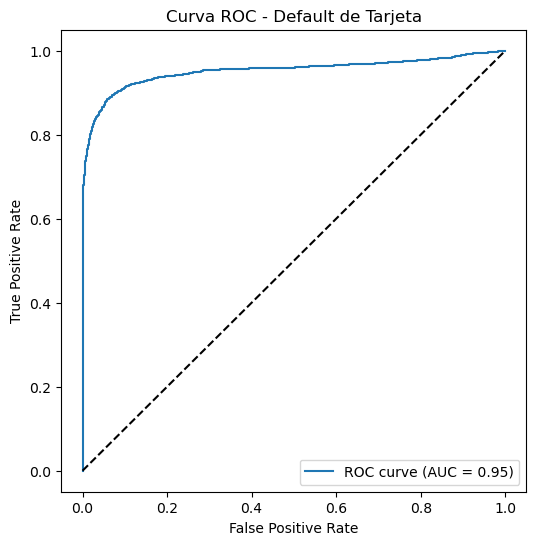


Coeficientes del modelo:
                                 Variable  Coeficiente
0                          annual_income    -0.000004
1                                    dti     0.096939
2                            installment     0.033983
3                               int_rate     0.105525
4                            loan_amount     0.000408
..                                   ...          ...
129                         sub_grade_G4     0.015617
130                         sub_grade_G5     0.002322
131     verification_status_Not Verified     0.022507
132  verification_status_Source Verified    -0.152438
133         verification_status_Verified    -0.028899

[134 rows x 2 columns]


In [38]:
# Variables independientes y dependiente
X = pbp_encoded.drop("loan_status", axis=1)
y = pbp_encoded['loan_status']
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Modelo de regresión logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predicciones
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

# Evaluación
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, digits=3))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Default de Tarjeta')
plt.legend(loc="lower right")
plt.show()

# Coeficientes interpretables
# Ese fragmento de código lo que hace es extraer y mostrar los coeficientes del modelo de regresión logística de manera ordenada en un DataFrame. 
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_reg.coef_[0]
})
print("\nCoeficientes del modelo:\n", coef_df)